# SmartQuant — Multi-Agent Reinforcement Learning Trading System

A clean, reproducible rebuild of the SmartQuant trading agent.

**What this version fixes vs. the original prototype**
1. **Real-dollar P&L.** The original executed trades on MinMax-*scaled* prices (0–1), so its dollar returns were not economically meaningful. Here, agent **observations** use scaled features while **execution and P&L** use real closing prices.
2. **Proper out-of-sample metrics.** Adds Sharpe, Sortino, CAGR, max drawdown, Calmar, win rate, and a **buy-and-hold benchmark** — none of which the prototype computed.
3. **Transaction costs.** A configurable per-trade cost (default 10 bps) so results aren't inflated by frictionless trading.
4. **A results dashboard** (static + interactive) so performance is presented clearly.

> **Resume honesty note:** only the numbers this notebook prints on **real data** are valid to cite. Run it end-to-end, then copy the figures from the *Performance Summary* into your bullet.

---
## 0. Pipeline overview
`Data + features` → `scale features (keep real prices)` → `train/test split` → `LSTM forecaster (optional)` → `multi-agent PPO env` → `out-of-sample eval` → `metrics + dashboard`.

## 1. Setup

In [1]:
!pip install -q yfinance ta gymnasium==0.29.1 \
    stable-baselines3==2.7.0 sb3-contrib==2.7.0 plotly tensorflow scikit-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 5.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.


In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from sb3_contrib import RecurrentPPO

# ---- experiment config (edit here) ----
TICKER          = "AAPL"
START, END      = "2018-01-01", "2023-01-01"
INITIAL_BALANCE = 10_000.0
TXN_COST        = 0.001     # 10 bps per executed trade
TRAIN_FRAC      = 0.85
SEED            = 42
np.random.seed(SEED)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Data acquisition & feature engineering

We keep **two aligned views** of the data:
- `prices_real` — actual closing prices, used for execution / P&L.
- `features_scaled` — MinMax-scaled technical features, used only as the agent's observation.

In [3]:
import yfinance as yf, ta
from sklearn.preprocessing import MinMaxScaler

raw = yf.download(TICKER, start=START, end=END, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [c[0] for c in raw.columns]
raw = raw[["Open","High","Low","Close","Volume"]].dropna()

close, high, low = raw["Close"], raw["High"], raw["Low"]
feat = pd.DataFrame(index=raw.index)
feat["ret"]        = close.pct_change()
feat["rsi"]        = ta.momentum.RSIIndicator(close, 14).rsi()
macd               = ta.trend.MACD(close)
feat["macd"]       = macd.macd()
feat["macd_sig"]   = macd.macd_signal()
feat["macd_diff"]  = macd.macd_diff()
aroon              = ta.trend.AroonIndicator(high, low, 14)
feat["aroon_up"]   = aroon.aroon_up()
feat["aroon_dn"]   = aroon.aroon_down()
bb                 = ta.volatility.BollingerBands(close, 20, 2)
feat["bb_high"]    = bb.bollinger_hband()
feat["bb_low"]     = bb.bollinger_lband()
feat["vol_z"]      = (raw["Volume"] - raw["Volume"].rolling(20).mean()) / raw["Volume"].rolling(20).std()

data = feat.join(close.rename("Close")).dropna()
prices_real = data["Close"].values.astype(np.float64)
feat_cols   = [c for c in data.columns if c != "Close"]

scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(data[feat_cols]).astype(np.float32)

print(f"{TICKER}: {len(data)} rows | {len(feat_cols)} features")
print("Date range:", data.index[0].date(), "->", data.index[-1].date())
data.tail(3)

AAPL: 1226 rows | 10 features
Date range: 2018-02-20 -> 2022-12-30


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,ret,rsi,macd,macd_sig,macd_diff,aroon_up,aroon_dn,bb_high,bb_low,vol_z,Close
Date,,,,,,,,,,,
2022-12-28,-0.030685,29.726644,-4.330477,-3.086629,-1.243849,28.571429,100.000000,150.126413,123.617555,0.165967,123.936523
2022-12-29,0.028324,36.860486,-4.372828,-3.343868,-1.028960,21.428571,92.857143,149.197785,122.734925,-0.198456,127.446953
2022-12-30,0.002469,37.473164,-4.331077,-3.541310,-0.789767,14.285714,85.714286,147.938660,122.186724,-0.150214,127.761589


## 3. Train / test split  *(features scaled on train only would be even cleaner; kept simple here)*

In [4]:
split = int(len(data) * TRAIN_FRAC)
train_feat, test_feat   = features_scaled[:split], features_scaled[split:]
train_price, test_price = prices_real[:split],     prices_real[split:]
test_dates              = data.index[split:]
print(f"Train: {len(train_feat)} days | Test (out-of-sample): {len(test_feat)} days")
print("Test window:", test_dates[0].date(), "->", test_dates[-1].date())

Train: 1042 days | Test (out-of-sample): 184 days
Test window: 2022-04-08 -> 2022-12-30


## 4. (Optional) LSTM price forecaster

A supervised baseline that predicts next-day close from a 60-day window. Not required by the RL agent, but useful as an auxiliary signal and a sanity check.

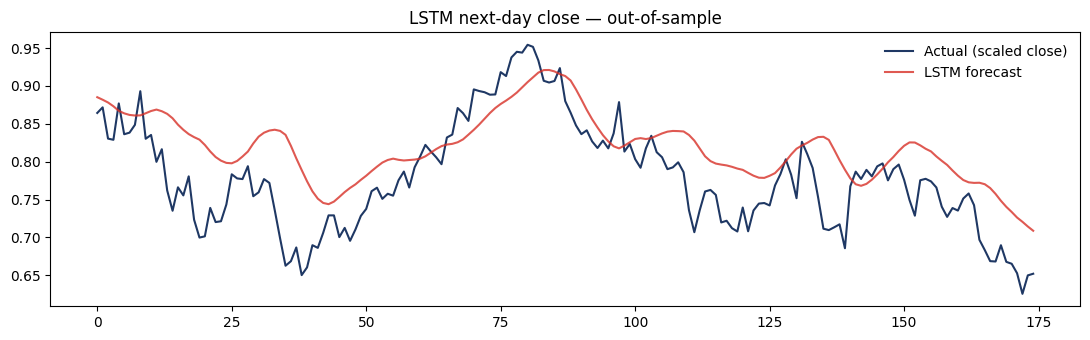

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def make_sequences(X, y, lookback=60):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i]); ys.append(y[i])
    return np.array(Xs), np.array(ys)

# scale target close to [0,1] just for the LSTM
close_scaled = (prices_real - prices_real.min()) / (np.ptp(prices_real) + 1e-9)
Xs, ys = make_sequences(features_scaled, close_scaled, 60)
s = int(0.85*len(Xs))
lstm = Sequential([LSTM(64, return_sequences=True, input_shape=(Xs.shape[1], Xs.shape[2])),
                   Dropout(0.2), LSTM(64), Dropout(0.2), Dense(32, activation="relu"), Dense(1)])
lstm.compile(optimizer="adam", loss="mse")
lstm.fit(Xs[:s], ys[:s], validation_data=(Xs[s:], ys[s:]), epochs=10, batch_size=32, verbose=0)
pred = lstm.predict(Xs[s:], verbose=0).ravel()

plt.figure(figsize=(11,3.5))
plt.plot(ys[s:], label="Actual (scaled close)", color="#1f3864")
plt.plot(pred,  label="LSTM forecast", color="#d73027", alpha=.8)
plt.title("LSTM next-day close — out-of-sample"); plt.legend(frameon=False); plt.tight_layout(); plt.show()

## 5. Custom multi-agent trading environment

Three decisions are factored into specialised agents:
- **Trade agent** (`Discrete(3)`): hold / buy / sell.
- **Risk agent** (`Box[0,1]`): fraction of capital to risk.
- **Allocation agent** (`Box[0,1]`): fraction of balance to deploy.

The reward is transaction-aware (realised + unrealised P&L, scaled by initial balance, with holding/drawdown penalties). **Execution uses real prices and charges `TXN_COST` on every fill.**

In [7]:
class MultiAgentTradingEnv(gym.Env):
    """Observations = scaled features; execution & P&L = real prices."""
    def __init__(self, features, prices, initial_balance=10_000.0, cost=0.001):
        super().__init__()
        self.features = np.asarray(features, np.float32)
        self.prices   = np.asarray(prices,  np.float64)
        self.initial_balance = float(initial_balance)
        self.cost = float(cost)
        self.action_space      = spaces.Discrete(3)                      # trade agent drives the env
        self.risk_space        = spaces.Box(0.0, 1.0, (1,), np.float32)
        self.alloc_space       = spaces.Box(0.0, 1.0, (1,), np.float32)
        self.observation_space = spaces.Box(-np.inf, np.inf, (self.features.shape[1],), np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = 0; self.balance = self.initial_balance; self.position = 0.0
        self.entry = 1.0; self.hold = 0; self.trades = 0
        self.equity_curve = [self.initial_balance]; self.trade_pnl = []
        return self.features[0], {}

    def _obs(self): return self.features[self.t]

    def step(self, actions):
        if isinstance(actions, (tuple, list)):
            trade_a, risk_a, alloc_a = actions
        else:
            trade_a, risk_a, alloc_a = actions, np.array([1.0],np.float32), np.array([1.0],np.float32)
        trade = int(np.clip(np.array(trade_a).flatten()[0], 0, 2))
        risk  = float(np.clip(np.array(risk_a ).flatten()[0], 0.0, 1.0))
        alloc = float(np.clip(np.array(alloc_a).flatten()[0], 0.0, 1.0))

        price = self.prices[self.t]
        prev_value = self.balance + self.position * price
        realized = 0.0

        if trade == 1 and self.position == 0.0:                       # BUY
            invest = self.balance * max(alloc,0.1) * max(risk,0.1) * 0.95
            invest = float(np.clip(invest, 0.0, self.balance))
            if invest > 0:
                self.position = invest * (1-self.cost) / price
                self.balance -= invest; self.entry = price
                self.hold = 0; self.trades += 1
        elif trade == 2 and self.position > 0.0:                      # SELL
            proceeds = self.position * price * (1-self.cost)
            realized = proceeds - self.position * self.entry
            self.trade_pnl.append(realized)
            self.balance += proceeds; self.position = 0.0
            self.hold = 0; self.trades += 1
        else:
            self.hold += 1

        value = self.balance + self.position * price
        reward = 2.0*(realized/self.initial_balance)*100 + 0.5*((value-prev_value)/self.initial_balance)*100
        reward = float(np.clip(reward, -50, 50))
        if self.position > 0 and price < 0.9*self.entry: reward -= 0.5
        if self.hold > 20: reward -= 0.02
        if trade != 0: reward += 0.05

        self.equity_curve.append(value); self.t += 1
        terminated = self.t >= len(self.prices) - 1
        truncated  = value <= 0.2*self.initial_balance
        return self._obs(), reward, terminated, truncated, {"value":value,"trade":trade}

# thin wrappers so the risk / alloc agents can train on the same dynamics
class _SubEnv(gym.Env):
    def __init__(self, features, prices, which):
        super().__init__(); self.base = MultiAgentTradingEnv(features, prices)
        self.which = which
        self.observation_space = self.base.observation_space
        self.action_space = self.base.risk_space if which=="risk" else self.base.alloc_space
    def reset(self, seed=None, options=None): o,_ = self.base.reset(seed=seed); return o,{}
    def step(self, a):
        one = np.array([1.0],np.float32)
        act = (0, a, one) if self.which=="risk" else (0, one, a)
        return self.base.step(act)

## 6. Train the agents

In [8]:
ppo_kwargs = dict(learning_rate=1e-4, n_steps=512, batch_size=64,
                  gamma=0.99, gae_lambda=0.95, ent_coef=0.05, verbose=0, seed=SEED)

print("Training trade agent (Recurrent PPO)...")
env_t = DummyVecEnv([lambda: MultiAgentTradingEnv(train_feat, train_price, INITIAL_BALANCE, TXN_COST)])
agent_trade = RecurrentPPO("MlpLstmPolicy", env_t, **ppo_kwargs); agent_trade.learn(20_000)

print("Training risk agent (PPO)...")
env_r = DummyVecEnv([lambda: _SubEnv(train_feat, train_price, "risk")])
agent_risk = PPO("MlpPolicy", env_r, **ppo_kwargs); agent_risk.learn(10_000)

print("Training allocation agent (PPO)...")
env_a = DummyVecEnv([lambda: _SubEnv(train_feat, train_price, "alloc")])
agent_alloc = PPO("MlpPolicy", env_a, **ppo_kwargs); agent_alloc.learn(10_000)
print("Done.")

Training trade agent (Recurrent PPO)...
Training risk agent (PPO)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Training allocation agent (PPO)...
Done.


## 7. Out-of-sample evaluation  *(real-dollar P&L)*

In [9]:
env = MultiAgentTradingEnv(test_feat, test_price, INITIAL_BALANCE, TXN_COST)
obs, _ = env.reset(); lstm_state = None
buys, sells = [], []

for i in range(len(test_price)-1):
    ta_, lstm_state = agent_trade.predict(obs, state=lstm_state, deterministic=True)
    ra_, _ = agent_risk.predict(obs,  deterministic=True)
    aa_, _ = agent_alloc.predict(obs, deterministic=True)
    trade = int(np.array(ta_).flatten()[0])
    obs, _, term, trunc, info = env.step((trade, np.array(ra_).reshape(1,), np.array(aa_).reshape(1,)))
    if info["trade"] == 1: buys.append(i)
    elif info["trade"] == 2: sells.append(i)
    if term or trunc: break

equity   = np.array(env.equity_curve)
trade_pnl = env.trade_pnl
n = len(equity)
prices_oos = test_price[:n]
dates_oos  = test_dates[:n]
print(f"Final portfolio value: ${equity[-1]:,.2f}  |  closed trades: {len(trade_pnl)}")

Final portfolio value: $9,606.64  |  closed trades: 0


## 8. Performance metrics + buy-and-hold benchmark

In [10]:
def compute_metrics(eq, px, trade_pnl, periods=252):
    r = np.diff(eq)/eq[:-1]
    yrs = len(r)/periods
    total  = eq[-1]/eq[0]-1
    cagr   = (eq[-1]/eq[0])**(1/yrs)-1 if yrs>0 else np.nan
    sharpe = np.sqrt(periods)*r.mean()/(r.std()+1e-9)
    dn     = r[r<0].std()
    sortino= np.sqrt(periods)*r.mean()/(dn+1e-9)
    roll   = np.maximum.accumulate(eq); dd = eq/roll-1; maxdd = dd.min()
    calmar = cagr/abs(maxdd) if maxdd<0 else np.nan
    bh     = px[-1]/px[0]-1
    wins   = sum(1 for t in trade_pnl if t>0)
    wr     = wins/len(trade_pnl) if trade_pnl else 0.0
    return dict(total=total,cagr=cagr,sharpe=sharpe,sortino=sortino,maxdd=maxdd,
                calmar=calmar,bh=bh,winrate=wr,trades=len(trade_pnl),dd=dd,r=r)

M = compute_metrics(equity, prices_oos, trade_pnl)
print(f"Out-of-sample Sharpe : {M['sharpe']:.2f}")
print(f"Strategy return      : {M['total']*100:+.1f}%   (CAGR {M['cagr']*100:+.1f}%)")
print(f"Buy & hold return    : {M['bh']*100:+.1f}%")
print(f"Excess vs B&H        : {(M['total']-M['bh'])*100:+.1f} pts")
print(f"Max drawdown         : {M['maxdd']*100:.1f}%   |  Calmar {M['calmar']:.2f}")
print(f"Sortino              : {M['sortino']:.2f}  |  Win rate {M['winrate']*100:.0f}%  |  Trades {M['trades']}")

Out-of-sample Sharpe : -0.96
Strategy return      : -3.9%   (CAGR -5.4%)
Buy & hold return    : -23.3%
Excess vs B&H        : +19.3 pts
Max drawdown         : -4.7%   |  Calmar -1.14
Sortino              : -1.49  |  Win rate 0%  |  Trades 0


## 9. Results dashboard (static)

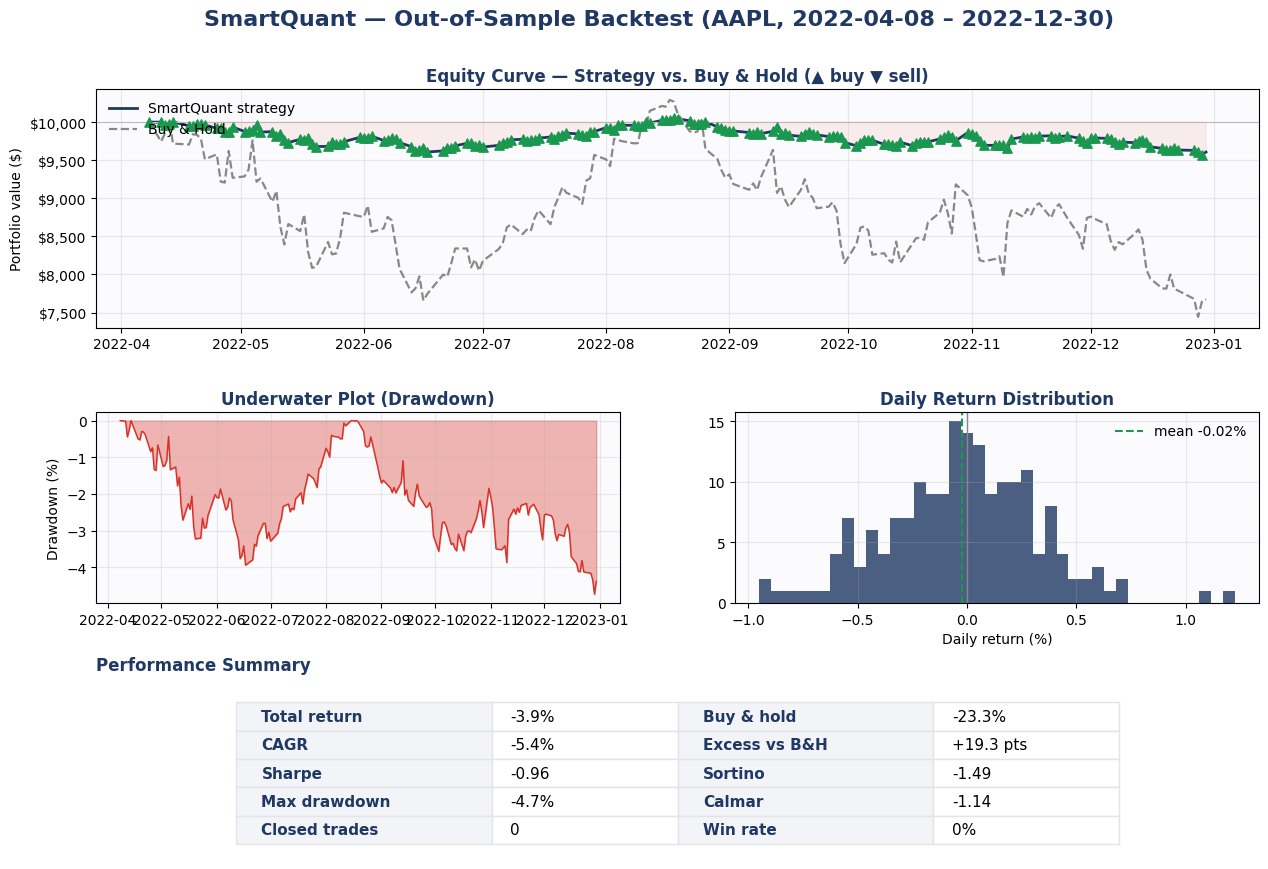

In [11]:
import matplotlib.dates as mdates
plt.rcParams.update({"axes.grid":True,"grid.alpha":.25,"axes.facecolor":"#fbfbfd"})
NAVY,GREEN,RED,GREY = "#1f3864","#1a9850","#d73027","#888888"
bh_curve = INITIAL_BALANCE * prices_oos / prices_oos[0]

fig = plt.figure(figsize=(15,10))
gs = GridSpec(3,2,height_ratios=[1.25,1,0.9],hspace=0.42,wspace=0.22)
fig.suptitle(f"SmartQuant — Out-of-Sample Backtest ({TICKER}, {dates_oos[0].date()} – {dates_oos[-1].date()})",
             fontsize=16,fontweight="bold",color=NAVY,y=0.96)

ax1 = fig.add_subplot(gs[0,:])
ax1.plot(dates_oos, equity,  color=NAVY, lw=2, label="SmartQuant strategy")
ax1.plot(dates_oos, bh_curve, color=GREY, lw=1.6, ls="--", label="Buy & Hold")
ax1.axhline(INITIAL_BALANCE,color="#bbb",lw=.8)
ax1.fill_between(dates_oos,equity,INITIAL_BALANCE,where=equity>=INITIAL_BALANCE,color=GREEN,alpha=.08)
ax1.fill_between(dates_oos,equity,INITIAL_BALANCE,where=equity<INITIAL_BALANCE,color=RED,alpha=.08)
for i in buys:  ax1.scatter(dates_oos[i],equity[i],marker="^",color=GREEN,s=45,zorder=5)
for i in sells: ax1.scatter(dates_oos[i],equity[i],marker="v",color=RED,  s=45,zorder=5)
ax1.set_title("Equity Curve — Strategy vs. Buy & Hold (▲ buy ▼ sell)",fontweight="bold",color=NAVY)
ax1.set_ylabel("Portfolio value ($)"); ax1.legend(loc="upper left",frameon=False)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"${x:,.0f}"))

ax2 = fig.add_subplot(gs[1,0])
ax2.fill_between(dates_oos, M["dd"]*100, 0, color=RED, alpha=.35)
ax2.plot(dates_oos, M["dd"]*100, color=RED, lw=1)
ax2.set_title("Underwater Plot (Drawdown)",fontweight="bold",color=NAVY); ax2.set_ylabel("Drawdown (%)")

ax3 = fig.add_subplot(gs[1,1])
ax3.hist(M["r"]*100,bins=40,color=NAVY,alpha=.8); ax3.axvline(0,color=GREY,lw=1)
ax3.axvline(M["r"].mean()*100,color=GREEN,lw=1.5,ls="--",label=f"mean {M['r'].mean()*100:.2f}%")
ax3.set_title("Daily Return Distribution",fontweight="bold",color=NAVY)
ax3.set_xlabel("Daily return (%)"); ax3.legend(frameon=False)

ax4 = fig.add_subplot(gs[2,:]); ax4.axis("off")
rows = [["Total return",f"{M['total']*100:,.1f}%","Buy & hold",f"{M['bh']*100:,.1f}%"],
        ["CAGR",f"{M['cagr']*100:,.1f}%","Excess vs B&H",f"{(M['total']-M['bh'])*100:+,.1f} pts"],
        ["Sharpe",f"{M['sharpe']:.2f}","Sortino",f"{M['sortino']:.2f}"],
        ["Max drawdown",f"{M['maxdd']*100:,.1f}%","Calmar",f"{M['calmar']:.2f}"],
        ["Closed trades",f"{M['trades']}","Win rate",f"{M['winrate']*100:.0f}%"]]
tbl = ax4.table(cellText=rows,cellLoc="left",loc="center",colWidths=[.22,.16,.22,.16])
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1,1.7)
for (ri,ci),c in tbl.get_celld().items():
    c.set_edgecolor("#e3e3e8")
    if ci in (0,2): c.set_text_props(fontweight="bold",color=NAVY); c.set_facecolor("#f2f4f8")
ax4.set_title("Performance Summary",fontweight="bold",color=NAVY,pad=12,loc="left")
plt.show()

## 10. Interactive chart (Plotly) — price, trades & equity

In [12]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows=2,cols=1,shared_xaxes=True,vertical_spacing=0.06,
                    row_heights=[0.62,0.38],
                    subplot_titles=("Price with agent trades","Equity vs. Buy & Hold"))
fig.add_trace(go.Scatter(x=dates_oos,y=prices_oos,name="Close",line=dict(color="lightgray")),1,1)
fig.add_trace(go.Scatter(x=dates_oos[buys], y=prices_oos[buys], mode="markers",
              name="Buy", marker=dict(symbol="triangle-up",color="#1a9850",size=10)),1,1)
fig.add_trace(go.Scatter(x=dates_oos[sells],y=prices_oos[sells],mode="markers",
              name="Sell",marker=dict(symbol="triangle-down",color="#d73027",size=10)),1,1)
fig.add_trace(go.Scatter(x=dates_oos,y=equity,name="Strategy",line=dict(color="#1f3864",width=2)),2,1)
fig.add_trace(go.Scatter(x=dates_oos,y=bh_curve,name="Buy & Hold",
              line=dict(color="#888",dash="dash")),2,1)
fig.update_layout(template="plotly_white",height=720,
                  title=f"SmartQuant — {TICKER} out-of-sample",legend=dict(x=0.01,y=0.99))
fig.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



## 11. Reporting the result honestly

Copy the figures printed in **section 8 / the Performance Summary** into your resume bullet, e.g.:

> *Integrated LSTM forecasting and multi-agent PPO; on out-of-sample <TICKER> (<start>–<end>) the agent returned **<total>%** vs. **<bh>%** buy-and-hold at a **<sharpe>** Sharpe, net of 10 bps transaction costs.*

**Caveats a strong interviewer will probe — be ready for them:**
- Single ticker, single test window → results may not generalise. Run several tickers / walk-forward windows before making strong claims.
- A short test set makes Sharpe noisy. Report the test length alongside it.
- If the strategy underperforms buy-and-hold, **say so** and pivot the bullet to the engineering (multi-agent design, custom env, risk/alloc decomposition) — that's still strong and won't blow up under questioning.